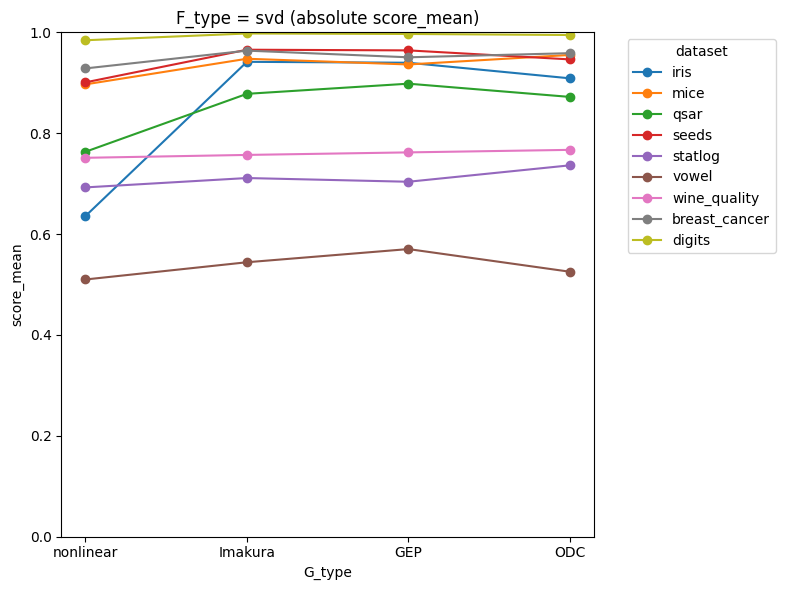

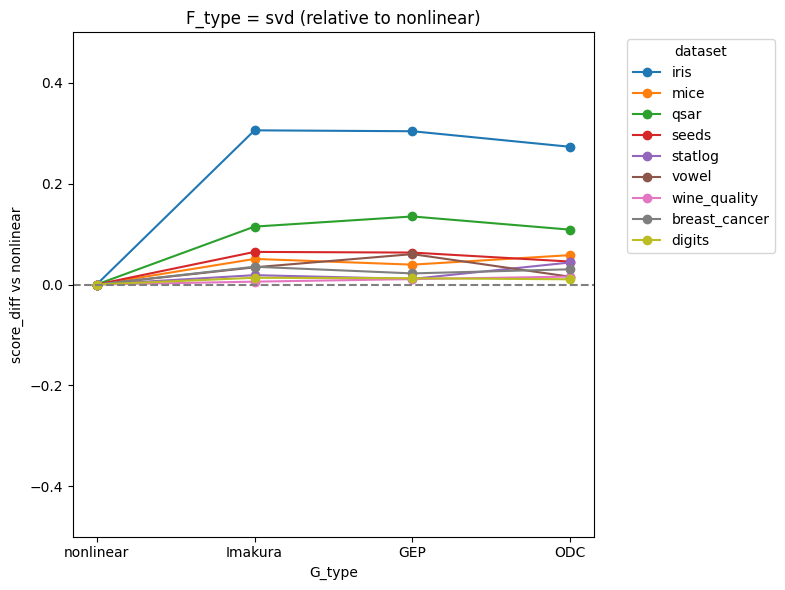

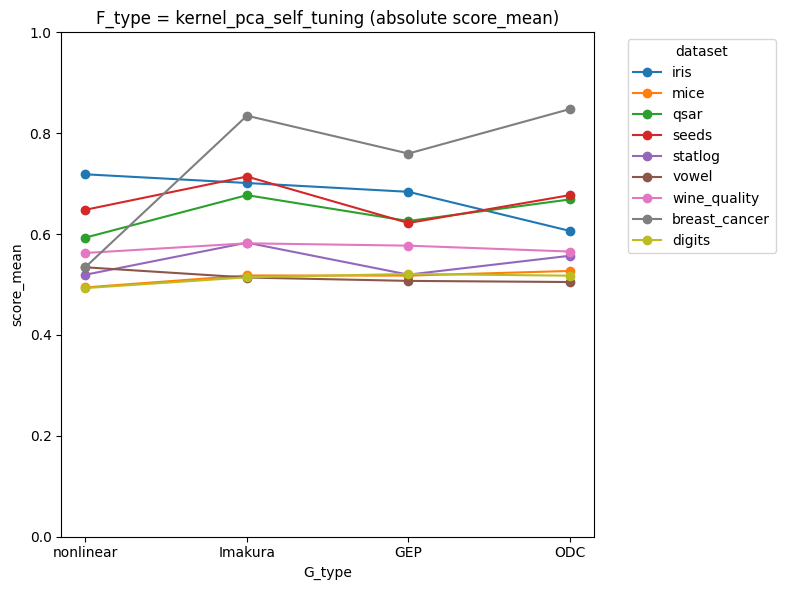

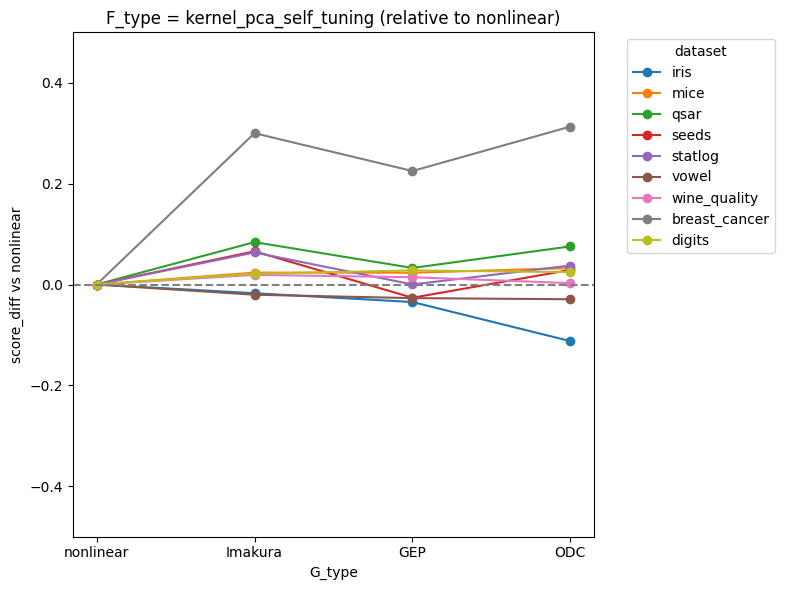

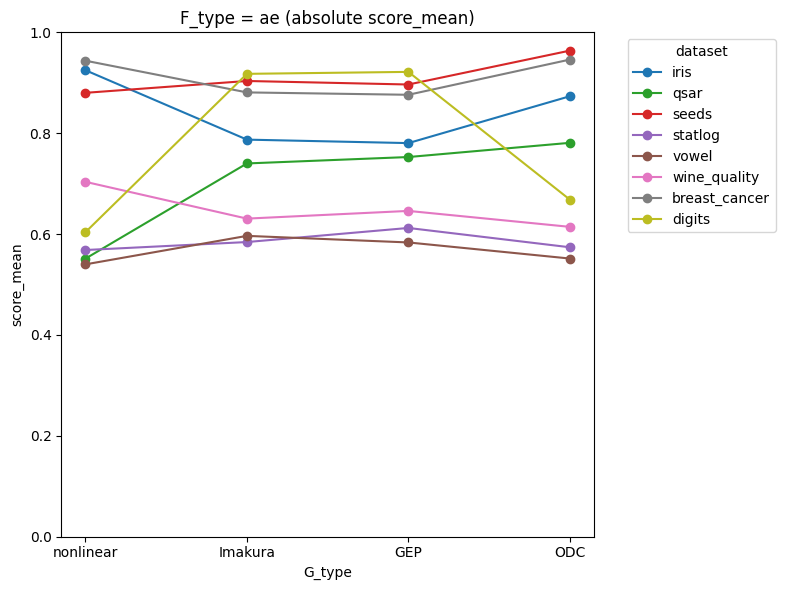

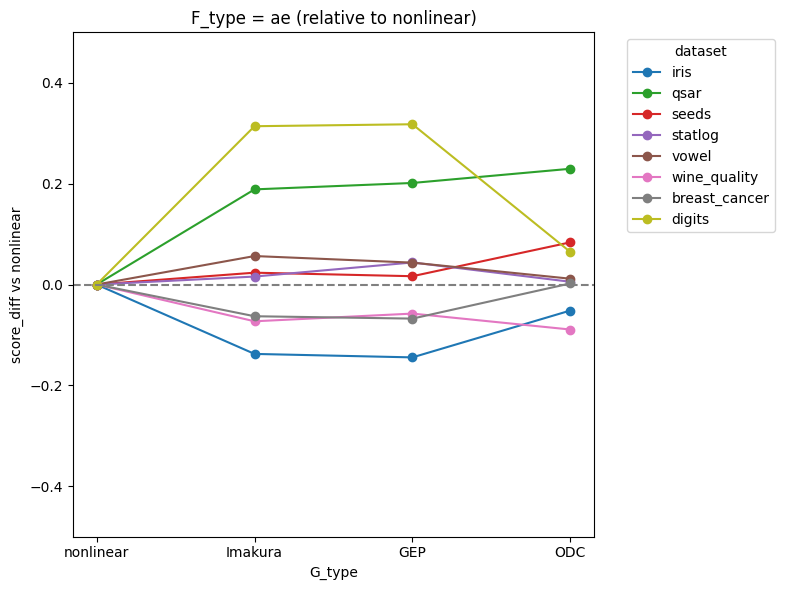

In [4]:
# ============================================
# 📘 Data Aggregation and Visualization Script
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.colors as mcolors

# =====================================================
# 🧩 Part 1. データ集計: CSV結合 + nonlinear基準の差分計算
# =====================================================

def load_and_aggregate_results(file_paths):
    """
    複数CSVファイルを結合し、nonlinear基準のscore差分を計算して返す。

    Parameters
    ----------
    file_paths : list of str
        各CSVファイルのパス。

    Returns
    -------
    pd.DataFrame
        結合済み・差分列(score_diff)付きのDataFrame。
    """
    dfs = []
    for f in file_paths:
        df = pd.read_csv(f)
        dataset_name = Path(f).stem.replace("result_grid_", "").replace("_new", "")
        df["dataset"] = dataset_name
        dfs.append(df)

    # 結合
    df_all = pd.concat(dfs, ignore_index=True)
    df_all = df_all[df_all["inter_normalization"]  == True]  # inter_normalization=True のみ抽出


    # nonlinearを基準に差分を計算
    baseline = df_all[df_all["G_type"] == "nonlinear"][["F_type", "dataset", "score_mean"]]
    baseline = baseline.rename(columns={"score_mean": "score_baseline"})
    merged = df_all.merge(baseline, on=["F_type", "dataset"], how="left")
    merged["score_diff"] = merged["score_mean"] - merged["score_baseline"]

    return merged


# =====================================================
# 🎨 Part 2. 可視化関数: 折れ線プロット (6グラフ)
# =====================================================

def plot_scores(df):
    """
    各F_typeごとに score_mean と score_diff を折れ線で描画。

    Parameters
    ----------
    df : pd.DataFrame
        `load_and_aggregate_results()` で作成したDataFrame
    """
    datasets = df["dataset"].unique()
    colors = dict(zip(datasets, list(mcolors.TABLEAU_COLORS.values())[:len(datasets)]))

    for f_type in df["F_type"].unique():
        subset = df[df["F_type"] == f_type]

        # --- (1) 絶対スコア ---
        plt.figure(figsize=(8, 6))
        for dataset in datasets:
            subdata = subset[subset["dataset"] == dataset]
            if len(subdata) > 0:
                plt.plot(subdata["G_type"], subdata["score_mean"],
                         marker="o", label=dataset, color=colors[dataset])
        plt.title(f"F_type = {f_type} (absolute score_mean)")
        plt.xlabel("G_type")
        plt.ylabel("score_mean")
        plt.ylim(0, 1)
        plt.legend(title="dataset", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

        # --- (2) nonlinearとの差分 ---
        plt.figure(figsize=(8, 6))
        for dataset in datasets:
            subdata = subset[subset["dataset"] == dataset]
            if len(subdata) > 0:
                plt.plot(subdata["G_type"], subdata["score_diff"],
                         marker="o", label=dataset, color=colors[dataset])
        plt.title(f"F_type = {f_type} (relative to nonlinear)")
        plt.xlabel("G_type")
        plt.ylabel("score_diff vs nonlinear")
        plt.ylim(-0.5, 0.5)
        plt.axhline(0, color="gray", linestyle="--")
        plt.legend(title="dataset", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()


# =====================================================
# 🚀 Part 3. 実行例
# =====================================================

# ファイル群（例: mice_new 差し替え済み）
file_paths = [
    "result_grid_iris.csv",
    "result_grid_mice_new.csv",
    "result_grid_qsar.csv",
    "result_grid_seeds.csv",
    "result_grid_statlog.csv",
    "result_grid_vowel.csv",
    "result_grid_wine_quality.csv",
    "result_grid_breast_cancer.csv",
    "result_grid_digits.csv",
]

# データ読み込み＆集計
df_final = load_and_aggregate_results(file_paths)

# 折れ線グラフ描画
plot_scores(df_final)
